In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from collections import deque
import sys
import time
import csv

In [2]:
class HybridPowerFlowOptimizer:
    """
    Optimizes power flow using a hybrid metaheuristic approach, incorporating
    local search, adaptive algorithm selection, stagnation handling, and
    adaptive parameters. Allows zero-cost load shedding.
    """

    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, initial_B, memory_size=100):
        """
        Initializes the HybridPowerFlowOptimizer.
        MODIFIED to disable initial clamping of generator limits.
        """
        self.A = A_matrix
        self.line_limits = np.array(line_limits, dtype=np.float64)
        self.num_lines = A_matrix.shape[0]
        self.num_buses = A_matrix.shape[1]
        self.tolerance = 1e-6

        self.initial_B = initial_B.copy().flatten()

        self.gen_indices = np.where(self.initial_B > self.tolerance)[0]
        self.load_indices = np.where(self.initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0:
            raise ValueError("No generator buses identified (initial B > 0). Cannot proceed.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices}) - Load shedding enabled (Zero Cost).")

        flat_gc = np.array(gen_costs).flatten()
        flat_gmin = np.array(gen_limits_min).flatten()
        flat_gmax = np.array(gen_limits_max).flatten()
        if len(flat_gc) != self.num_buses or len(flat_gmin) != self.num_buses or len(flat_gmax) != self.num_buses:
            raise ValueError(f"Generator cost/limit array length mismatch (Expected {self.num_buses})")
        self.gen_costs_only = flat_gc[self.gen_indices]
        self.gen_limits_min_only = flat_gmin[self.gen_indices]
        self.gen_limits_max_only = flat_gmax[self.gen_indices]
        if np.any(self.gen_limits_max_only < self.gen_limits_min_only):
            raise ValueError("Generator Max limit cannot be less than Min limit.")

        self.initial_B_load_fixed = self.initial_B[self.load_indices]
        self.load_limits_min_only = self.initial_B_load_fixed
        self.load_limits_max_only = np.zeros_like(self.load_limits_min_only)

        needs_adjust = False

        # MODIFICATION: Initial clamping is disabled. The raw user input for generator
        # injections will be used as the starting point, and any limit violations
        # will be handled by the fitness function during optimization.
        #
        # # Clamp initial generator values to their min/max limits if they are outside.
        # initial_gen_values = self.initial_B[self.gen_indices]
        # if np.any(initial_gen_values < self.gen_limits_min_only - self.tolerance) or \
        #    np.any(initial_gen_values > self.gen_limits_max_only + self.tolerance):
        #     print("Warning: Initial generator B outside limits. Clamping...")
        #     self.initial_B[self.gen_indices] = np.clip(initial_gen_values, self.gen_limits_min_only, self.gen_limits_max_only)
        #     needs_adjust = True

        required_total_injection = 0.0
        current_total_injection = np.sum(self.initial_B)
        difference_init = required_total_injection - current_total_injection
        num_gens = len(self.gen_indices)

        if abs(difference_init) > self.tolerance * self.num_buses:
            print(f"Warning: Initial injections sum to {current_total_injection:.4f} (≠ 0). Adjusting generators to balance...")
            if num_gens > 0:
                diff_per_gen_init = difference_init / num_gens
                adjusted_gens = self.initial_B[self.gen_indices] + diff_per_gen_init
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)
                actual_adjustment_applied = np.sum(clipped_adjusted_gens) - np.sum(self.initial_B[self.gen_indices])
                self.initial_B[self.gen_indices] = clipped_adjusted_gens
                remaining_diff = difference_init - actual_adjustment_applied
                if abs(remaining_diff) > self.tolerance * self.num_buses:
                    print(f"Warning: Could not fully balance initial state due to gen limits. Remaining imbalance: {remaining_diff:.4f}")
                needs_adjust = True
            else:
                print("ERROR: Cannot balance initial state - no generators identified.")
                needs_adjust = True

        if needs_adjust:
            print("-> Adjusted initial B state used for optimization:", np.round(self.initial_B, 4))

        self.memory = deque(maxlen=memory_size)
        self.stagnation_threshold = 50
        self.diversification_fraction = 0.2

    def _apply_constraints(self, solution_vector):
        sol = solution_vector.copy().flatten()
        num_gens = len(self.gen_indices)
        num_loads = len(self.load_indices)

        if num_loads > 0:
            sol[self.load_indices] = np.clip(sol[self.load_indices], self.load_limits_min_only, self.load_limits_max_only)

        if num_gens > 0:
            sol[self.gen_indices] = np.clip(sol[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only)

        if num_gens > 0:
            current_load_sum = np.sum(sol[self.load_indices]) if num_loads > 0 else 0.0
            required_gen_sum = -current_load_sum
            current_gen_sum = np.sum(sol[self.gen_indices])
            difference = required_gen_sum - current_gen_sum

            if abs(difference) > self.tolerance * self.num_buses:
                adjustment_per_gen = difference / num_gens
                adjusted_gens = sol[self.gen_indices] + adjustment_per_gen
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)
                sol[self.gen_indices] = clipped_adjusted_gens

        return sol.reshape(-1, 1)

    def _calculate_fitness(self, solution):
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)): return np.inf

        try:
            C = np.dot(self.A, sol_flat)
            if not np.all(np.isfinite(C)): return np.inf
            flows = C.flatten()
        except ValueError:
            return np.inf

        penalty_multiplier = 1e10
        line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        gen_limit_penalty = 0.0
        if len(self.gen_indices) > 0:
            gen_values = sol_flat[self.gen_indices]
            violations_lower_g = np.maximum(0, self.gen_limits_min_only - gen_values + self.tolerance)
            violations_upper_g = np.maximum(0, gen_values - self.gen_limits_max_only - self.tolerance)
            gen_limit_penalty = penalty_multiplier * (np.sum(violations_lower_g**2) + np.sum(violations_upper_g**2))

        load_limit_penalty = 0.0
        if len(self.load_indices) > 0:
            load_values = sol_flat[self.load_indices]
            violations_lower_l = np.maximum(0, self.load_limits_min_only - load_values + self.tolerance)
            violations_upper_l = np.maximum(0, load_values - self.load_limits_max_only - self.tolerance)
            load_limit_penalty = penalty_multiplier * (np.sum(violations_lower_l**2) + np.sum(violations_upper_l**2))

        balance_violation = abs(np.sum(sol_flat))
        balance_penalty = penalty_multiplier * (balance_violation**2) if balance_violation > self.tolerance * self.num_buses else 0.0

        generator_deviation = self._get_generator_deviation(solution)
        deviation_penalty_component = 1e5 * generator_deviation
        gen_rescheduling_cost = self._get_rescheduling_cost(solution)
        gen_cost_weight = 0.1

        fitness = (line_violation_penalty + gen_limit_penalty + load_limit_penalty + balance_penalty +
                   deviation_penalty_component + gen_cost_weight * gen_rescheduling_cost)
        return fitness if np.isfinite(fitness) else np.inf

    def _is_feasible(self, solution, verbose=False):
        if solution is None:
            if verbose: print("DEBUG (_is_feasible): Input solution is None.")
            return False
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)):
            if verbose: print("DEBUG (_is_feasible): Solution contains non-finite values.")
            return False

        try:
            flows = np.dot(self.A, sol_flat).flatten()
            line_ok = np.all(np.abs(flows) <= self.line_limits + self.tolerance)
        except Exception as e:
            line_ok = False
            if verbose: print(f"DEBUG: Line check error: {e}")

        gen_values = sol_flat[self.gen_indices] if len(self.gen_indices) > 0 else np.array([])
        gen_ok = (len(self.gen_indices) == 0 or
                  (len(gen_values) == len(self.gen_limits_min_only) and
                   np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and
                   np.all(gen_values <= self.gen_limits_max_only + self.tolerance)))

        load_values = sol_flat[self.load_indices] if len(self.load_indices) > 0 else np.array([])
        load_ok = (len(self.load_indices) == 0 or
                   (len(load_values) == len(self.load_limits_min_only) and
                    np.all(load_values >= self.load_limits_min_only - self.tolerance) and
                    np.all(load_values <= self.load_limits_max_only + self.tolerance)))

        bal_ok = abs(np.sum(sol_flat)) < self.tolerance * self.num_buses
        feasible = line_ok and gen_ok and load_ok and bal_ok

        if verbose or not feasible:
            print(f"--- Feasibility Check {'FAILED' if not feasible else 'PASSED'} ---")
            if not line_ok:
                failing_lines = np.where(np.abs(flows) > self.line_limits + self.tolerance)[0]
                print(f"  Line constraints failed. Failing lines: {failing_lines+1}")
                for idx in failing_lines[:5]:
                    if idx < len(flows) and idx < len(self.line_limits):
                        print(f"    Line {idx+1}: Flow={abs(flows[idx]):.4f}, Limit={self.line_limits[idx]:.4f}")
            else:
                print("  Line constraints met.")
            if not gen_ok:
                print("  Generator limits failed.")
            else:
                print("  Generator limits met.")
            if not load_ok:
                print("  Load limits failed.")
            else:
                print("  Load limits met.")
            if not bal_ok:
                print(f"  Power balance check failed, sum={np.sum(sol_flat):.8f}")
            else:
                print("  Power balance met.")
            print("-" * 40)
        return feasible

    def _get_generator_deviation(self, solution):
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0
        return np.sum(np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices]))

    def _get_rescheduling_cost(self, solution):
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0
        deviation = np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices])
        return np.sum(self.gen_costs_only * deviation)

    def _generate_random_solution(self):
        rand_sol = self.initial_B.copy()
        n_gens = len(self.gen_indices)
        if n_gens > 0:
            gen_range = np.maximum(self.tolerance, self.gen_limits_max_only - self.gen_limits_min_only)
            perturbations = (np.random.rand(n_gens) - 0.5) * gen_range * 0.2
            rand_sol[self.gen_indices] = np.clip(self.initial_B[self.gen_indices] + perturbations,
                                                  self.gen_limits_min_only, self.gen_limits_max_only)
        n_loads = len(self.load_indices)
        if n_loads > 0:
            potential_increase = np.random.rand(n_loads) * np.abs(self.initial_B[self.load_indices]) * 0.1
            rand_sol[self.load_indices] = np.clip(self.initial_B[self.load_indices] + potential_increase,
                                                   self.load_limits_min_only, self.load_limits_max_only)
        return self._apply_constraints(rand_sol)

    def _apply_local_search(self, solution, iteration, max_iterations):
        current_solution = solution.copy()
        current_fitness = self._calculate_fitness(current_solution)
        if not np.isfinite(current_fitness): return solution

        progress_ratio = iteration / max_iterations
        step_scale_factor = 0.1 * (1.0 - progress_ratio) + 0.01 * progress_ratio
        num_attempts = min(5, int(np.sqrt(self.num_buses)))

        for _ in range(num_attempts):
            idx_to_perturb = random.randrange(self.num_buses)
            perturbed_solution = current_solution.copy()
            perturb_range = 1.0
            if idx_to_perturb in self.gen_indices:
                gen_idx_local = np.where(self.gen_indices == idx_to_perturb)[0][0]
                gen_op_range = self.gen_limits_max_only[gen_idx_local] - self.gen_limits_min_only[gen_idx_local]
                perturb_range = max(self.tolerance, gen_op_range) * step_scale_factor
            elif idx_to_perturb in self.load_indices:
                load_idx_local = np.where(self.load_indices == idx_to_perturb)[0][0]
                load_op_range = self.load_limits_max_only[load_idx_local] - self.load_limits_min_only[load_idx_local]
                perturb_range = max(self.tolerance, load_op_range) * step_scale_factor

            perturbation = (random.random() - 0.5) * 2 * perturb_range
            perturbed_solution[idx_to_perturb, 0] += perturbation
            refined_solution = self._apply_constraints(perturbed_solution)
            refined_fitness = self._calculate_fitness(refined_solution)

            if np.isfinite(refined_fitness) and refined_fitness < current_fitness:
                current_solution = refined_solution
                current_fitness = refined_fitness
        return current_solution

    def optimize(self, B_unused, iterations=200, population_size=30, log_filename=None):
        print(f"Starting Optimization: Pop={population_size}, Iterations={iterations}")
        if log_filename:
            print(f"Logging iteration data to: {log_filename}")

        log_file, csv_writer = None, None
        if log_filename:
            try:
                header = ["Iteration", "Best_Fitness", "Stagnation_Counter", "Total_Load_Shed",
                          "Gen_Deviation_Sum", "Gen_Rescheduling_Cost", "Num_Line_Violations",
                          "Max_Line_Violation_Pct", "Prob_OOA", "Prob_KHA", "Prob_SHO"] + \
                         [f"B_{i+1}" for i in range(self.num_buses)]
                log_file = open(log_filename, 'w', newline='')
                csv_writer = csv.writer(log_file)
                csv_writer.writerow(header)
            except IOError as e:
                print(f"Warning: Could not open log file '{log_filename}'. Logging disabled. Error: {e}")
                log_file, csv_writer = None, None

        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = self._apply_constraints(self.initial_B)
        fitness_values = [self._calculate_fitness(sol) for sol in initial_population]
        best_idx = np.argmin(fitness_values)
        best_solution = initial_population[best_idx].copy()
        best_fitness = fitness_values[best_idx]

        if not np.isfinite(best_fitness):
            print("ERROR: Initial best fitness is non-finite. Cannot proceed with this population.")
            finite_indices = np.where(np.isfinite(fitness_values))[0]
            if len(finite_indices) > 0:
                best_idx = finite_indices[np.argmin(np.array(fitness_values)[finite_indices])]
                best_solution = initial_population[best_idx].copy()
                best_fitness = fitness_values[best_idx]
                print(f"Warning: Using first finite solution found as initial best (Fitness: {best_fitness:.4e})")
            else:
                print("FATAL: No finite fitness found in initial population. Returning initial B.")
                return self.initial_B.reshape(-1, 1), [], np.dot(self.A, self.initial_B.reshape(-1,1))

        print(f"Initial Best Fitness: {best_fitness:.4e}")
        fitness_history = [best_fitness]
        algorithm_names = ['OOA', 'KHA', 'SHO']
        algo_success_count = {name: 0 for name in algorithm_names}
        algo_attempts_count = {name: 0 for name in algorithm_names}
        algo_probabilities = {name: 1.0 / len(algorithm_names) for name in algorithm_names}
        adaptation_rate, stagnation_counter, last_best_fitness = 0.05, 0, best_fitness

        try:
            for iteration in range(iterations):
                total_attempts = sum(algo_attempts_count.values())
                if total_attempts > 0:
                    success_rates = {name: algo_success_count[name] / algo_attempts_count[name] if algo_attempts_count[name] > 0 else 0 for name in algorithm_names}
                    total_rate = sum(success_rates.values())
                    if total_rate > 1e-6:
                        target_probabilities = {name: rate / total_rate for name, rate in success_rates.items()}
                        for name in algorithm_names:
                            algo_probabilities[name] = (1 - adaptation_rate) * algo_probabilities[name] + adaptation_rate * target_probabilities[name]
                        prob_sum = sum(algo_probabilities.values())
                        if prob_sum > 1e-6:
                            algo_probabilities = {name: p / prob_sum for name, p in algo_probabilities.items()}
                        else:
                            algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}

                current_weights = list(algo_probabilities.values())
                if not (len(current_weights) == len(algorithm_names) and abs(sum(current_weights) - 1.0) < 1e-5 and all(w >= 0 for w in current_weights)):
                    current_weights = [1.0/len(algorithm_names)] * len(algorithm_names)

                new_population = list(initial_population)
                new_fitness_values = list(fitness_values)

                for i in range(population_size):
                    algorithm = random.choices(algorithm_names, weights=current_weights, k=1)[0]
                    algo_attempts_count[algorithm] += 1
                    
                    if algorithm == 'OOA': candidate_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    elif algorithm == 'KHA': candidate_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    else: candidate_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    
                    refined_candidate = self._apply_local_search(candidate_solution, iteration, iterations)
                    new_solution = self._apply_constraints(refined_candidate)
                    new_fitness = self._calculate_fitness(new_solution)

                    if new_fitness < new_fitness_values[i]:
                        new_population[i] = new_solution
                        new_fitness_values[i] = new_fitness

                    if new_fitness < best_fitness:
                        best_fitness = new_fitness
                        best_solution = new_solution.copy()
                        algo_success_count[algorithm] += 1
                
                initial_population = new_population
                fitness_values = new_fitness_values

                if abs(best_fitness - last_best_fitness) < self.tolerance * max(1.0, abs(last_best_fitness)):
                    stagnation_counter += 1
                else:
                    stagnation_counter, last_best_fitness = 0, best_fitness

                if stagnation_counter >= self.stagnation_threshold:
                    print(f"\nStagnation detected at iteration {iteration}. Diversifying population...")
                    num_to_replace = int(population_size * self.diversification_fraction)
                    worst_indices = np.argsort(fitness_values)[-num_to_replace:]
                    for idx in worst_indices:
                        initial_population[idx] = self._generate_random_solution()
                        fitness_values[idx] = self._calculate_fitness(initial_population[idx])
                    
                    current_best_idx_after_diversify = np.argmin(fitness_values)
                    if fitness_values[current_best_idx_after_diversify] < best_fitness:
                        best_solution = initial_population[current_best_idx_after_diversify].copy()
                        best_fitness = fitness_values[current_best_idx_after_diversify]
                    
                    last_best_fitness = best_fitness
                    stagnation_counter = 0

                if csv_writer:
                    best_sol_flat = best_solution.flatten()
                    flows = np.dot(self.A, best_sol_flat).flatten()
                    line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
                    num_line_violations = np.sum(line_violations > 0)
                    safe_limits = np.where(self.line_limits > self.tolerance, self.line_limits, self.tolerance)
                    max_line_violation_pct = np.max(line_violations / safe_limits) * 100 if num_line_violations > 0 else 0.0
                    gen_dev, gen_cost = self._get_generator_deviation(best_solution), self._get_rescheduling_cost(best_solution)
                    load_shed_amount = np.sum(np.maximum(0, best_sol_flat[self.load_indices] - self.initial_B[self.load_indices])) if len(self.load_indices) > 0 else 0.0
                    
                    log_row = [iteration, best_fitness, stagnation_counter, load_shed_amount, gen_dev, gen_cost,
                               num_line_violations, max_line_violation_pct] + list(algo_probabilities.values()) + best_sol_flat.tolist()
                    csv_writer.writerow(log_row)

                if iteration % 100 == 0 or iteration == iterations - 1:
                    deviation = self._get_generator_deviation(best_solution)
                    cost = self._get_rescheduling_cost(best_solution)
                    print(f"Iter {iteration}/{iterations}: BestFit={best_fitness:.4e}, Deviation={deviation:.3f}, GenCost={cost:.2f} (Stagnation: {stagnation_counter}/{self.stagnation_threshold})")
                
                fitness_history.append(best_fitness)
        finally:
            if log_file:
                log_file.close()
                print(f"Finished logging iteration data to {log_filename}.")

        best_solution = self._apply_constraints(best_solution)
        final_C = np.dot(self.A, best_solution)
        
        return best_solution, fitness_history, final_C
    
    def _apply_orcas_optimization(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        a = 2 * (1 - (iteration / max_iterations)**2)
        r1, r2 = random.random(), random.random()
        if r1 < 0.5:
            step = a * r2 * (best_sol_flat - sol_flat)
            new_solution_flat = sol_flat + step
        else:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_solution_idx = random.choice(other_indices) if other_indices else current_index
            random_solution = population[random_solution_idx].flatten()
            A_param = 2 * a * r1 - a
            C_param = 2 * r2
            D_param = np.abs(C_param * random_solution - sol_flat)
            new_solution_flat = random_solution - A_param * D_param
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)

    def _apply_krill_herd(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        Dmax = 0.005 * (1 - iteration / max_iterations)
        Vf, Nmax, Dt = 0.02, 0.01, 1.0
        N_induced = Nmax * (best_sol_flat - sol_flat)
        F_foraging = Vf * (best_sol_flat - sol_flat)
        diffusion_vector = np.random.uniform(-1, 1, sol_flat.shape)
        D_physical = Dmax * diffusion_vector
        new_solution_flat = sol_flat + Dt * (N_induced + F_foraging + D_physical)
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)

    def _apply_spotted_hyena(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        h = 5 - iteration * (5 / max_iterations)
        B_param = 2 * random.random()
        E_param = 2 * h * random.random() - h
        D_best = np.abs(B_param * best_sol_flat - sol_flat)
        X1 = best_sol_flat - E_param * D_best
        if abs(E_param) >= 1:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_hyena_idx = random.choice(other_indices) if other_indices else current_index
            random_hyena = population[random_hyena_idx].flatten()
            D_hyena = np.abs(B_param * random_hyena - sol_flat)
            new_solution_flat = random_hyena - E_param * D_hyena
        else:
            new_solution_flat = X1
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)


In [3]:
def optimize_power_flow_free_loadshed(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max,
                                      iterations=5000, population_size=100, log_filename=None):
    print("--- Initializing Optimizer (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---")
    try:
        optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)
    except (ValueError, NameError) as e:
        print(f"ERROR initializing optimizer: {e}")
        return B, [], np.full((A.shape[0], 1), np.nan), np.full((A.shape[0], 1), np.nan), False, {}

    initial_B_from_opt = optimizer.initial_B.reshape(-1, 1)
    try:
        C_unoptimized = np.dot(A, initial_B_from_opt)
    except Exception as e:
        print(f"Warning: Could not calculate initial flows: {e}")
        C_unoptimized = np.full((A.shape[0], 1), np.nan)

    print("\n--- Checking Initial State Feasibility (Using Optimizer's Initial State) ---")
    initial_feasible = optimizer._is_feasible(initial_B_from_opt, verbose=True)
    if not initial_feasible:
        print("WARNING: Optimizer starting from an infeasible state.")

    print("\n--- Starting Optimization (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---")
    B_opt, fit_hist, C_opt = optimizer.optimize(None, iterations=iterations, population_size=population_size, log_filename=log_filename)

    print("\n--- Checking Final Solution Feasibility ---")
    final_feasible = optimizer._is_feasible(B_opt, verbose=True)
    print(f"\nFinal feasibility: {final_feasible}")
    details = {"gen_indices": optimizer.gen_indices, "load_indices": optimizer.load_indices}
    return B_opt, fit_hist, C_opt, C_unoptimized, final_feasible, details

In [4]:
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      gen_costs, gen_limits_min, gen_limits_max,
                      gen_indices, load_indices, fitness_history):
    num_lines, num_buses = A.shape
    print("\n--- Generating Plots ---")
    
    # Plot 1: Line Flows
    plt.figure(figsize=(14, 7))
    idx = np.arange(1, num_lines + 1)
    unoptimized_flows_abs = np.abs(C_unoptimized.flatten())
    optimized_flows_abs = np.abs(C_optimized.flatten())
    colors_unoptimized = ['crimson' if flow > limit + 1e-6 else 'skyblue' for flow, limit in zip(unoptimized_flows_abs, line_limits)]
    plt.bar(idx - 0.2, unoptimized_flows_abs, width=0.4, label='Unoptimized Flow', color=colors_unoptimized)
    plt.bar(idx + 0.2, optimized_flows_abs, width=0.4, label='Optimized Flow', color='forestgreen')
    plt.plot(idx, line_limits, 'k--', label='Line Limit')
    plt.xlabel('Line Index')
    plt.ylabel('Absolute Power Flow')
    plt.title('Line Flow Comparison')
    plt.legend()
    plt.grid(True, axis='y', linestyle=':')
    plt.show()

    # Plot 2: Fitness Convergence
    if fitness_history and len(fitness_history) > 1:
        plt.figure(figsize=(10, 5))
        plt.plot(fitness_history, '.-')
        plt.xlabel('Iteration')
        plt.ylabel('Fitness Value (Log Scale)')
        plt.title('Optimization Convergence')
        plt.yscale('log')
        plt.grid(True)
        plt.show()

Loading system matrix A from: lock.csv
System dimensions: 20 lines, 14 buses.

========================= New Scenario =========================
Using hardcoded scenario data for demonstration.

--- Running Optimization ---
--- Initializing Optimizer (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---
Identified 2 generator buses (indices: [0 1])
Identified 12 load buses (indices: [ 2  3  4  5  6  7  8  9 10 11 12 13]) - Load shedding enabled (Zero Cost).

--- Checking Initial State Feasibility (Using Optimizer's Initial State) ---
--- Feasibility Check FAILED ---
  Line constraints failed. Failing lines: [1]
    Line 1: Flow=158.8662, Limit=100.0000
  Generator limits met.
  Load limits met.
  Power balance met.
----------------------------------------

--- Starting Optimization (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---
Starting Optimization: Pop=100, Iterations=5000
Logging iteration data to: optimization_log_20250621-155308.csv
Initial Best Fitness: 2.1630e+13
Iter 0/50

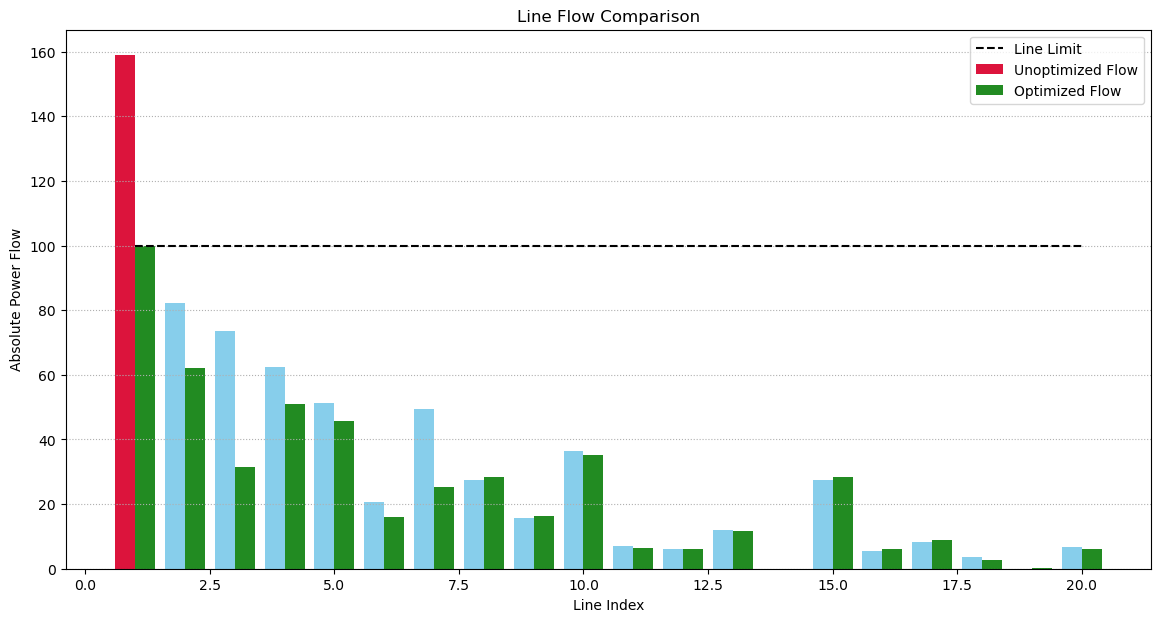

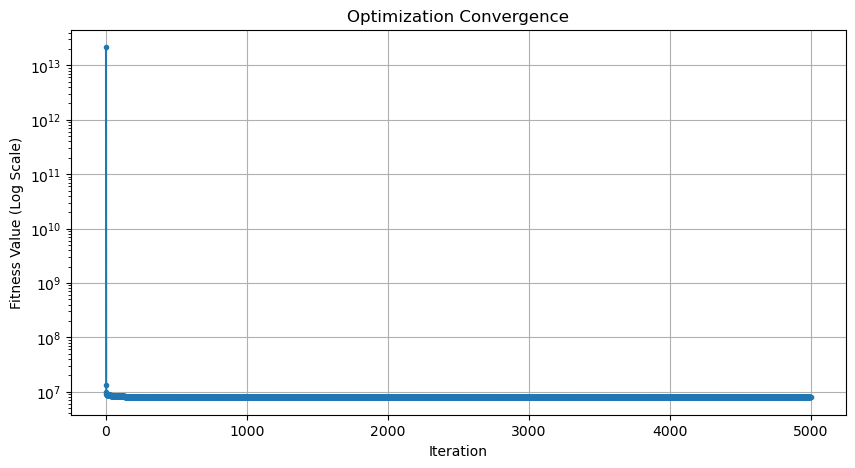

In [ ]:
if __name__ == "__main__":
    matrix_file_name = 'lock.csv'
    try:
        print(f"Loading system matrix A from: {matrix_file_name}")
        A = pd.read_csv(matrix_file_name, header=None).to_numpy()
        if A.ndim != 2 or A.shape[0] == 0 or A.shape[1] == 0:
            raise ValueError("Loaded matrix A is not valid.")
        num_lines_main, num_buses_main = A.shape
        print(f"System dimensions: {num_lines_main} lines, {num_buses_main} buses.")
    except Exception as e:
        print(f"FATAL ERROR loading '{matrix_file_name}': {e}. Exiting.")
        sys.exit()

    while True:
        print("\n" + "="*25 + " New Scenario " + "="*25)
        
        # Using hardcoded values for this example instead of interactive input
        print("Using hardcoded scenario data for demonstration.")
        line_limits_input = np.full(num_lines_main, 100.0)
        B_input_list = [241, 28.3, -94.2, -47.8, -47.6, -11.2, 0, 0, -29.50, -9, -3.5, -6.1, -5.5, -14.9]
        if len(B_input_list) != num_buses_main:
            print(f"Error: Example B_input length mismatch. Exiting.")
            break
        B_input = np.array(B_input_list).reshape(-1, 1)
        
        temp_gen_indices = np.where(B_input.flatten() > 1e-6)[0]
        gen_costs_input = np.zeros(num_buses_main)
        gen_limits_min_input = np.zeros(num_buses_main)
        gen_limits_max_input = np.zeros(num_buses_main)
        
        gen_costs_input[temp_gen_indices] = [15, 20] 
        gen_limits_min_input[temp_gen_indices] = [50, 10]
        gen_limits_max_input[temp_gen_indices] = [250, 50]
        
        print("\n--- Running Optimization ---")
        try:
            opt_iterations = 5000
            opt_pop_size = 100
            
            log_csv_filename = f"optimization_log_{time.strftime('%Y%m%d-%H%M%S')}.csv"
            
            start_time = time.time()
            B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details = optimize_power_flow_free_loadshed(
                A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                iterations=opt_iterations,
                population_size=opt_pop_size,
                log_filename=log_csv_filename
            )
            end_time = time.time()
            print(f"Optimization Duration: {end_time - start_time:.2f} seconds")

        except Exception as e:
            print(f"An unexpected error occurred during the optimization run: {e}")
            break

        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                          opt_details.get("gen_indices", []), opt_details.get("load_indices", []), 
                          fitness_history)
        
        try:
            run_again = input("\nRun another scenario? (y/n):").strip().lower()
            if run_again != 'y':
                break
        except EOFError:
            break
            
    print("\nScript finished.")
